In [32]:
from tools.utils import replace_minus_ones_with_prev
from pathlib import Path
import pandas as pd
import numpy as np
from tqdm.auto import tqdm
import seaborn as sns


In [33]:
labeldist = []
for cl in ['anti-scraping', 'modification','arbitration',]: # 'opt-out','class waiver',
    df = pd.read_csv(f'annotations/ollama_annotations/{cl}_labels_judged.csv', index_col=0)
    labeldist.append(df['label_gpt-4o'].value_counts())

In [34]:
pd.concat(labeldist, axis=1, keys=['opt-out','arbitration','class waiver','anti-scraping', 'modification']).fillna(0).sum(axis=0)

/var/folders/d2/ydv0grbd38985h6_95t0vdjw0000gp/T/ipykernel_88698/660404432.py:1: FutureWarning: The behavior of pd.concat with len(keys) != len(objs) is deprecated. In a future version this will raise instead of truncating to the smaller of the two sequences
  pd.concat(labeldist, axis=1, keys=['opt-out','arbitration','class waiver','anti-scraping', 'modification']).fillna(0).sum(axis=0)


opt-out         1266
arbitration     1136
class waiver    1183
dtype: int64

In [4]:
processed_data_dir = Path('processed_data/tous')
file_name = processed_data_dir / 'metadata_annotated_distilbert.tsv' # _annotated_distilbert
metadata = pd.read_csv(file_name,sep='\t')
metadata['year_int'] = metadata.year.apply(lambda x: int(str(x)[:4]))
metadata.fillna('', inplace=True)

In [35]:
metadata.shape

(233880, 10)

In [36]:

threshold = 0.9
for clause_type in [ 'modification']: # 'opt-out','arbitration','class waiver','anti-scraping',
    metadata[f'{clause_type}_recoded'] = 0
    metadata.loc[metadata[f'prob_1_{clause_type}'] >= threshold, f'{clause_type}_recoded'] = 1
    

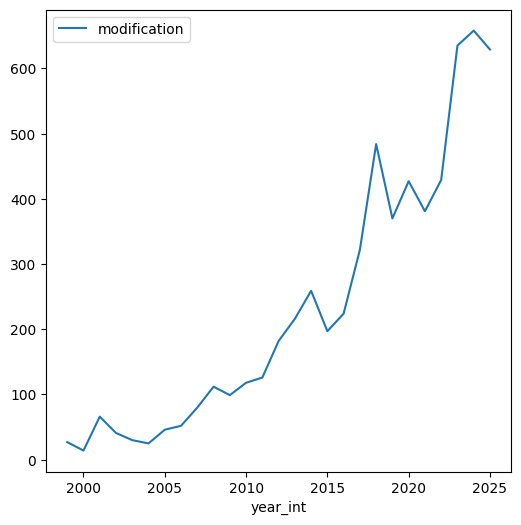

In [37]:
for clause_type in ['modification']: # 'opt-out','arbitration','class waiver','anti-scraping', 'modification'
    metadata.groupby('year_int')[f'{clause_type}_recoded'].sum().plot(legend=True, label=clause_type, figsize=(6,6))

In [38]:
clause_type = 'modification' # 'opt-out' | 'arbitration' | 'class waiver' | 'anti-scraping' | 'modification'
metadata.groupby(f'{clause_type}_recoded').size()

modification_recoded
0    227631
1      6249
dtype: int64

In [39]:
metadata[metadata.modification_recoded == 1].sentence

11        Uber may amend the Terms related to the Servic...
12        Amendments will be effective upon Ubers postin...
13        Your continued access or use of the Services a...
147       Notwithstanding the provisions of the modifica...
148       In order to be effective, the notice must incl...
                                ...                        
233817    Modifying the Services; Modifying these Terms ...
233818    For modifications to these Terms or the Servic...
233853    Ireland UK Germany France Spain Italy All othe...
233854    Your continued use of the Services after the e...
233855    For modifications to the Terms or to the Servi...
Name: sentence, Length: 6249, dtype: object

In [40]:

data = metadata.groupby(['platform','year_int'])[f'{clause_type}_recoded'].sum().astype(bool).astype(int).unstack().fillna(-1)
#data = metadata.groupby(['platform','year_int'])[f'prob_1_{clause_type}'].max().unstack().fillna(-1)


In [41]:
embeddings = np.loadtxt('processed_data/tous/embedding.tsv')

In [42]:
embeddings_clause = embeddings[metadata[metadata[f'{clause_type}_recoded'] == 1].index]
metadata_clause = metadata[metadata[f'{clause_type}_recoded'] == 1][['platform','year_int','sentence']]

In [43]:
len(metadata),embeddings.shape,embeddings_clause.shape,len(metadata_clause)

(233880, (233880, 768), (6249, 768), 6249)

In [44]:
metadata.head()

,platform,year,sentence,sentence_processed,sentence_processed_2,logits_modification,prob_1_modification,modification,year_int,modification_recoded
0,uber,20150201,Terms and Conditions Last Updated: February 10...,terms and conditions last updated : [mask] [ma...,terms and conditions last updated: february 10...,"tensor([[0.7534, 0.2466]])",0.246627,0.0,2015,0
1,uber,20150201,Contractual Relationship These Terms of Use (T...,contractual relationship these terms of use ( ...,contractual relationship these terms of use (t...,"tensor([[0.9943, 0.0057]])",0.005722,0.0,2015,0
2,uber,20150201,PLEASE READ THESE TERMS CAREFULLY BEFORE ACCES...,please read these terms carefully before acces...,please read these terms carefully before acces...,"tensor([[0.9124, 0.0876]])",0.087633,0.0,2015,0
3,uber,20150201,"In this Agreement, the words including and inc...","in this agreement , the words including and in...","in this agreement, the words including and inc...","tensor([[0.9771, 0.0229]])",0.022909,0.0,2015,0
4,uber,20150201,Your access and use of the Services constitute...,your access and use of the services constitute...,your access and use of the services constitute...,"tensor([[0.9938, 0.0062]])",0.006230,0.0,2015,0


In [45]:
# Influence-network setup for modification clauses
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
from IPython.display import display

from tools.influence_analysis_helpers import (
    _prepare_nodes_and_embeddings,
    _build_time_influence_edges,
    _build_within_platform_update_edges,
    _build_coordination_edges,
)

# --- Parameters you can tune ---
SIM_THRESHOLD = 0.93                 # cosine similarity threshold for influence edges
COORD_SIM_THRESHOLD = 0.93           # cosine similarity threshold for coordination edges
MAX_INFLUENCE_LAG_YEARS = 10         # only connect from up to N years in the past
K_CLOSEST_PER_PLATFORM = 2           # retained for coordination/local analyses (not used in first-occurrence cross-platform attribution)
COORD_TIME_WINDOW = 1                # |year_i - year_j| <= window for coordination
TOP_N_SENTENCES = 20                 # reporting/plotting cut-off

In [46]:
# Build temporal influence and coordination edges
nodes_df, emb_norm = _prepare_nodes_and_embeddings(metadata_clause, embeddings_clause)

# Cross-platform, first-occurrence attribution edges
influence_edges_df = _build_time_influence_edges(
    nodes=nodes_df,
    emb=emb_norm,
    sim_threshold=SIM_THRESHOLD,
    max_lag=MAX_INFLUENCE_LAG_YEARS,
    k_closest=K_CLOSEST_PER_PLATFORM,
)

# Within-platform carry-over edges (previous update -> next update)
within_platform_edges_df = _build_within_platform_update_edges(
    nodes=nodes_df,
    emb=emb_norm,
    sim_threshold=SIM_THRESHOLD,
    max_lag=MAX_INFLUENCE_LAG_YEARS,
)

# For influence scores we combine both edge types
influence_edges_for_scores_df = pd.concat([
    influence_edges_df,
    within_platform_edges_df,
], ignore_index=True)

coord_edges_df = _build_coordination_edges(
    nodes=nodes_df,
    emb=emb_norm,
    sim_threshold=COORD_SIM_THRESHOLD,
    time_window=COORD_TIME_WINDOW,
    k_closest=K_CLOSEST_PER_PLATFORM,
)

# Directed influence graph for scoring (cross-platform + within-platform carry-over)
G_infl = nx.from_pandas_edgelist(
    influence_edges_for_scores_df,
    source='source',
    target='target',
    edge_attr=['similarity', 'lag_years', 'source_platform', 'target_platform', 'source_year', 'target_year'],
    create_using=nx.DiGraph(),
)

for _, row in nodes_df.iterrows():
    n = int(row['node_id'])
    if n not in G_infl:
        G_infl.add_node(n)
    G_infl.nodes[n]['platform'] = row['platform']
    G_infl.nodes[n]['year'] = int(row['year'])
    G_infl.nodes[n]['sentence'] = row['sentence']

print(f'Nodes: {len(nodes_df):,}')
print(f'Cross-platform influence edges: {len(influence_edges_df):,}')
print(f'Within-platform carry-over edges: {len(within_platform_edges_df):,}')
print(f'Total edges for influence scoring: {len(influence_edges_for_scores_df):,}')
print(f'Coordination edges: {len(coord_edges_df):,}')
display(influence_edges_for_scores_df.head(5))

Building influence edges (first occurrence):   0%|          | 0/6249 [00:00<?, ?it/s]

Building coordination edges:   0%|          | 0/6249 [00:00<?, ?it/s]

Nodes: 6,249
Cross-platform influence edges: 2,152
Within-platform carry-over edges: 4,667
Total edges for influence scoring: 6,819
Coordination edges: 1,089


,source,target,similarity,lag_years,source_platform,target_platform,source_year,target_year,source_sentence,target_sentence
0,5707,7,0.937391,10,snapchat,uber,2014,2024,Your continued use of the Services will confir...,"You should regularly review these Terms, as yo..."
1,5707,10,0.937391,10,snapchat,uber,2014,2024,Your continued use of the Services will confir...,"You should regularly review these Terms, as yo..."
2,5707,16,0.937391,10,snapchat,uber,2014,2024,Your continued use of the Services will confir...,"You should regularly review these Terms, as yo..."
3,270,21,0.932159,10,twitter,uber,2011,2021,By continuing to access or use the Services af...,"If you do not agree to the amended Terms, you ..."
4,270,25,0.932159,10,twitter,uber,2011,2021,By continuing to access or use the Services af...,"If you do not agree to the amended Terms, you ..."


In [48]:
influence_edges_df.to_csv(f'results/tous/influence_edges_{clause_type}.tsv', sep='\t', index=False)

In [18]:
# Sentence-level and platform-level influence
weighted_out = dict(G_infl.out_degree(weight='similarity'))
out_degree = dict(G_infl.out_degree())
in_degree = dict(G_infl.in_degree())

influence_scores = nodes_df[['node_id', 'platform', 'year', 'sentence']].copy()
influence_scores['weighted_out'] = influence_scores['node_id'].map(weighted_out).fillna(0.0)
influence_scores['out_degree'] = influence_scores['node_id'].map(out_degree).fillna(0).astype(int)
influence_scores['in_degree'] = influence_scores['node_id'].map(in_degree).fillna(0).astype(int)
influence_scores['influence_score'] = influence_scores['weighted_out'] + 0.25 * influence_scores['out_degree']

top_sentences = influence_scores.sort_values('influence_score', ascending=False).head(TOP_N_SENTENCES).copy()
top_sentences['sentence_short'] = top_sentences['sentence'].str.slice(0, 180)

print('Top influential sentences:')
display(top_sentences[['platform', 'year', 'influence_score', 'weighted_out', 'out_degree', 'in_degree', 'sentence_short']])

platform_influence = (
    influence_scores
    .groupby('platform', as_index=False)['influence_score']
    .sum()
    .sort_values('influence_score', ascending=False)
    .reset_index(drop=True)
)

print('Top influential platforms:')
display(platform_influence.head(20))

Top influential sentences:


,platform,year,influence_score,weighted_out,out_degree,in_degree,sentence_short
3356,wechat,2014,65.135852,51.385852,55,0,Where we consider that any changes to these Te...
3357,wechat,2014,57.193942,45.193942,48,1,By continuing to use our services after we mak...
5598,instagram,2018,49.792120,39.292120,42,1,"Unless otherwise required by law, we will noti..."
1592,canva,2013,44.247087,34.997087,37,1,Your continued use of the Service after any su...
1205,google,2012,43.844308,34.594308,37,1,If you do not agree to the modified terms for ...
3881,paypal,2018,40.000000,32.000000,32,0,If you do not agree with any changes to this u...
3895,paypal,2011,39.183473,31.183473,32,1,The revised version will be effective at the t...
3882,paypal,2018,38.746505,30.996505,31,0,"If this information changes, we may update it ..."
3879,paypal,2018,38.554075,30.554075,32,0,If our changes reduce your rights or increase ...
5705,snapchat,2014,38.177484,30.177484,32,1,We may change or modify these Terms at any tim...


Top influential platforms:


,platform,influence_score
0,paypal,884.138149
1,ebay,629.783306
2,venmo,513.791495
3,gofundme,512.439872
4,yahoo,389.385517
5,tumblr,297.800649
6,grindr,280.129119
7,fb,260.764645
8,canva,259.577750
9,match,229.412468


In [49]:
influence_scores

,node_id,platform,year,sentence,weighted_out,out_degree,in_degree,influence_score
0,0,uber,2015,Uber may amend the Terms related to the Servic...,1.982437,2,1,2.482437
1,1,uber,2015,Amendments will be effective upon Ubers postin...,0.000000,0,1,0.000000
2,2,uber,2015,Your continued access or use of the Services a...,3.871179,4,1,4.871179
3,3,uber,2015,Notwithstanding the provisions of the modifica...,0.999329,1,1,1.249329
4,4,uber,2015,"In order to be effective, the notice must incl...",0.935943,1,1,1.185943
...,...,...,...,...,...,...,...,...
6244,6244,yahoo,2021,Modifying the Services; Modifying these Terms ...,0.000000,0,1,0.000000
6245,6245,yahoo,2021,For modifications to these Terms or the Servic...,0.000000,0,2,0.000000
6246,6246,yahoo,2021,Ireland UK Germany France Spain Italy All othe...,0.000000,0,1,0.000000
6247,6247,yahoo,2021,Your continued use of the Services after the e...,0.000000,0,2,0.000000


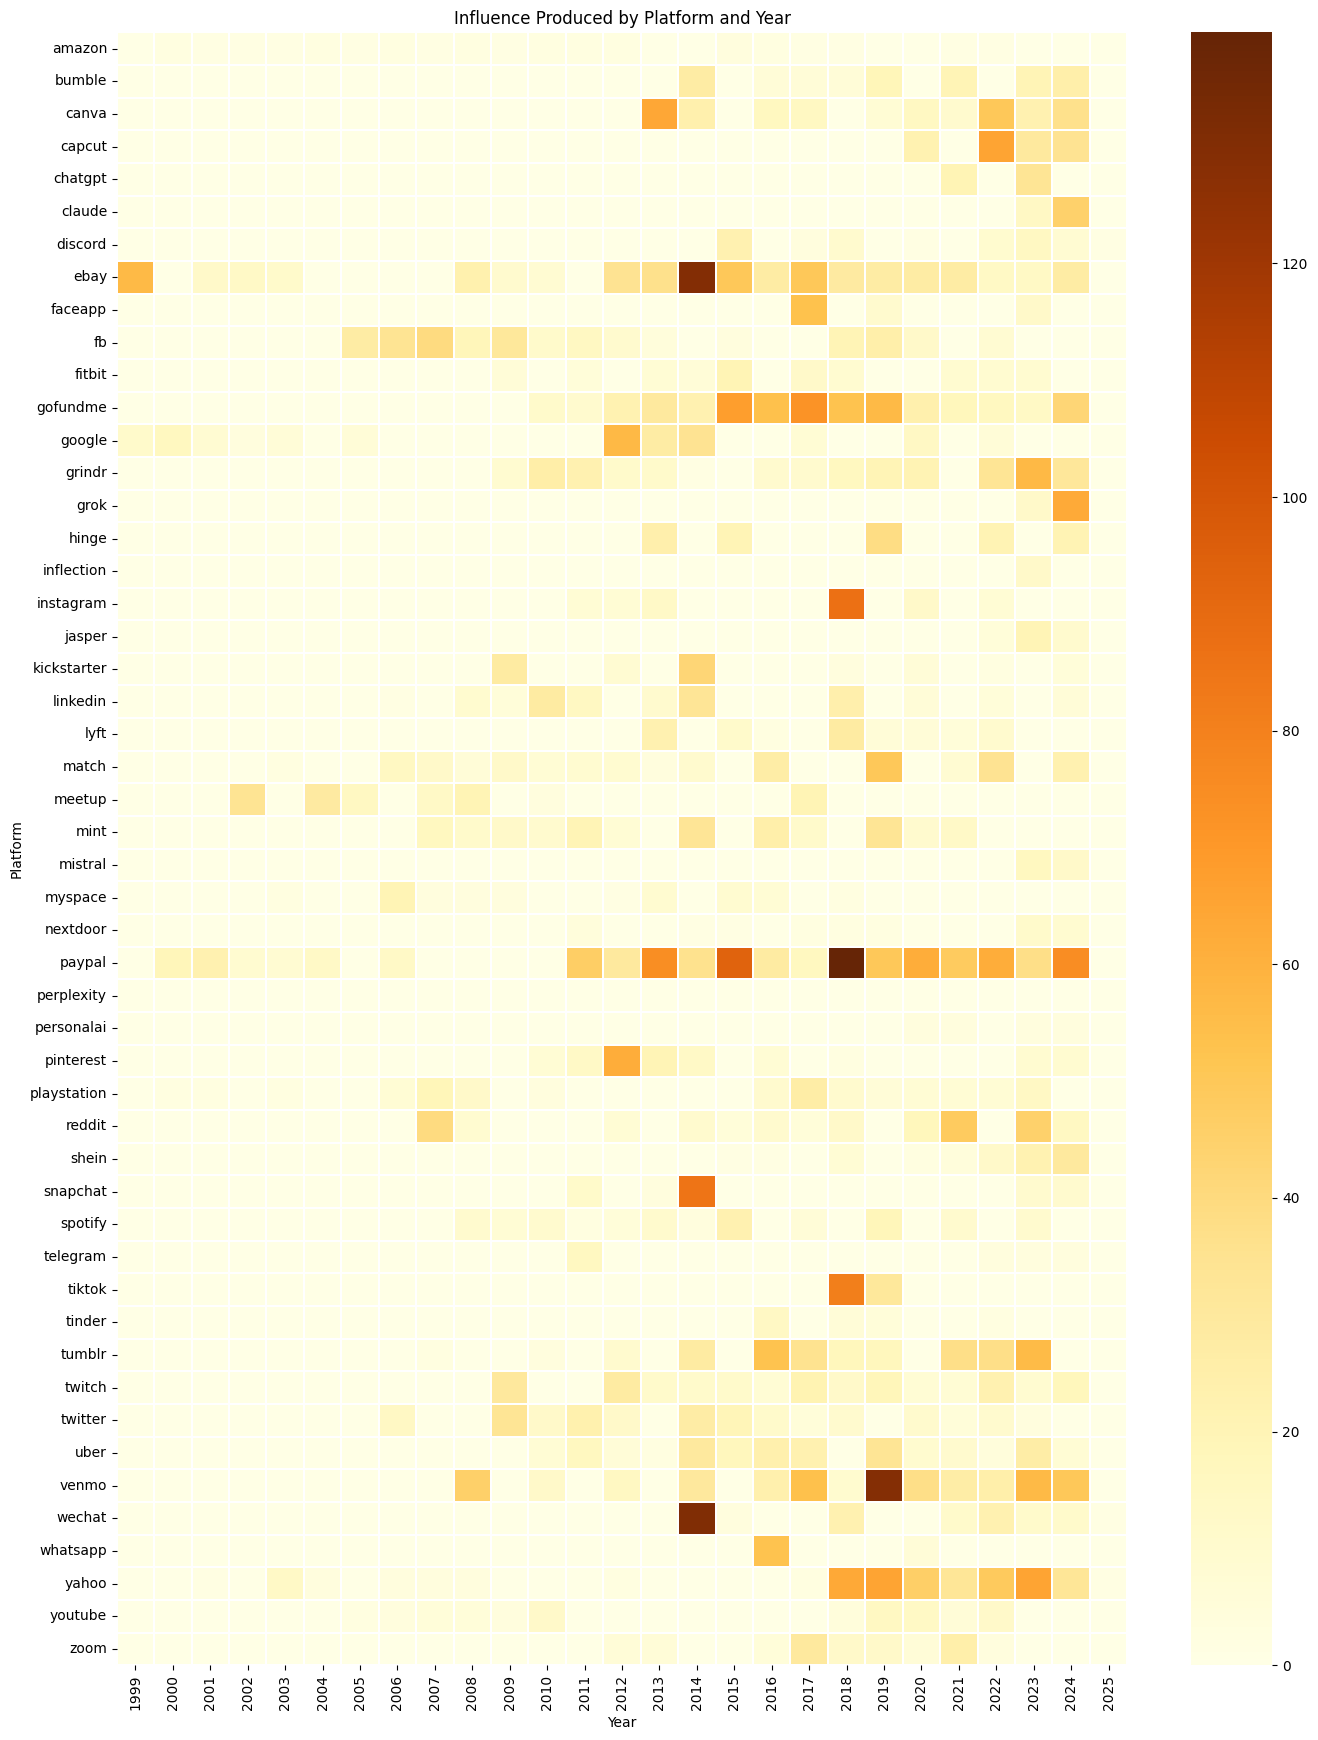

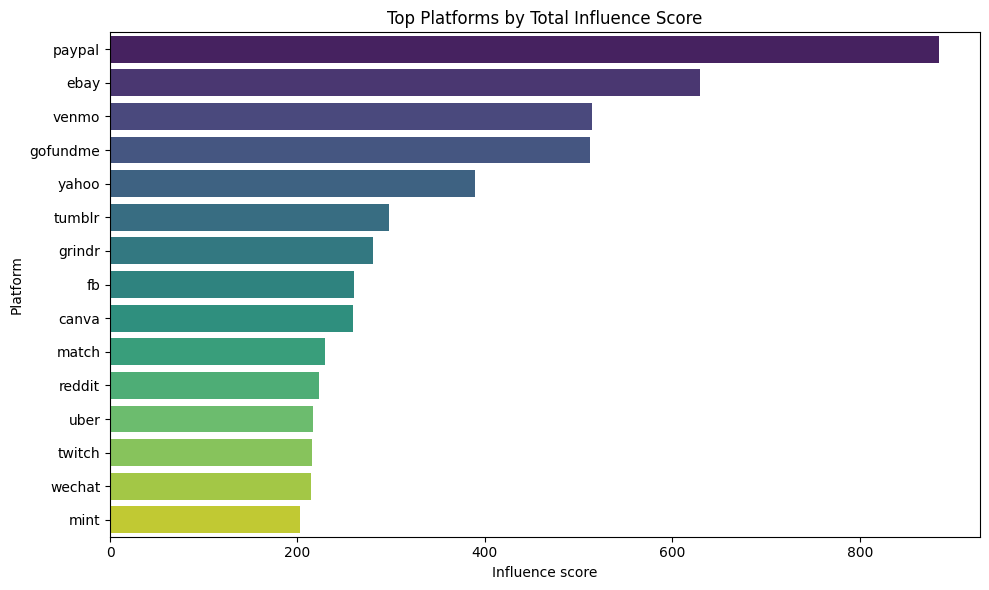

,year,platform,influence_score
0,1999,ebay,56.702436
1,2000,paypal,18.470728
2,2001,paypal,22.398747
3,2002,meetup,34.252425
4,2003,yahoo,13.346783
5,2004,meetup,28.445448
6,2005,fb,27.809541
7,2006,fb,34.224613
8,2007,fb,39.433879
9,2008,venmo,45.319621


In [19]:
# Visualization A: who developed influential sentences, and when
platform_year_influence = (
    influence_scores
    .groupby(['platform', 'year'], as_index=False)['influence_score']
    .sum()
)

pivot_inf = platform_year_influence.pivot(index='platform', columns='year', values='influence_score').fillna(0)

plt.figure(figsize=(14, max(6, 0.35 * len(pivot_inf))))
sns.heatmap(pivot_inf, cmap='YlOrBr', linewidths=0.2)
plt.title('Influence Produced by Platform and Year')
plt.xlabel('Year')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(data=platform_influence.head(15), y='platform', x='influence_score', palette='viridis')
plt.title('Top Platforms by Total Influence Score')
plt.xlabel('Influence score')
plt.ylabel('Platform')
plt.tight_layout()
plt.show()

yearly_top = (
    platform_year_influence.sort_values(['year', 'influence_score'], ascending=[True, False])
    .groupby('year', as_index=False)
    .first()
)
display(yearly_top.head(20))

In [20]:
# Coordination summary: are platforms adopting similar clauses at the same time?
if coord_edges_df.empty:
    print('No coordination edges found at current threshold/window. Lower COORD_SIM_THRESHOLD or increase COORD_TIME_WINDOW.')
else:
    coord_edges_df = coord_edges_df.copy()
    coord_edges_df['platform_pair'] = coord_edges_df.apply(
        lambda r: ' | '.join(sorted([r['u_platform'], r['v_platform']])), axis=1
    )
    coord_edges_df['same_year'] = (coord_edges_df['u_year'] == coord_edges_df['v_year']).astype(int)
    coord_edges_df['abs_year_gap'] = (coord_edges_df['u_year'] - coord_edges_df['v_year']).abs()

    same_year_ratio = coord_edges_df['same_year'].mean()
    print(f'Share of coordinated edges in same year: {same_year_ratio:.3f}')

    coord_by_pair = (
        coord_edges_df
        .groupby('platform_pair', as_index=False)
        .agg(
            n_edges=('similarity', 'size'),
            mean_similarity=('similarity', 'mean'),
            same_year_share=('same_year', 'mean'),
        )
        .sort_values(['n_edges', 'mean_similarity'], ascending=False)
    )

    display(coord_by_pair.head(25))

    coord_by_year = (
        coord_edges_df
        .assign(mid_year=((coord_edges_df['u_year'] + coord_edges_df['v_year']) / 2).round().astype(int))
        .groupby('mid_year', as_index=False)
        .agg(
            n_edges=('similarity', 'size'),
            mean_similarity=('similarity', 'mean'),
            same_year_share=('same_year', 'mean'),
        )
        .sort_values('mid_year')
    )

    display(coord_by_year.head(30))

Share of coordinated edges in same year: 0.687


,platform_pair,n_edges,mean_similarity,same_year_share
196,paypal | venmo,50,0.990702,0.880000
92,ebay | paypal,29,0.946392,0.758621
103,fb | instagram,25,0.962943,0.840000
214,reddit | twitter,24,0.948220,0.916667
70,claude | reddit,24,0.947660,1.000000
206,personalai | yahoo,22,0.933157,0.727273
8,canva | gofundme,21,0.969348,1.000000
136,hinge | match,20,0.995905,0.900000
160,kickstarter | reddit,17,0.947153,0.647059
217,reddit | zoom,15,0.942471,0.200000


,mid_year,n_edges,mean_similarity,same_year_share
0,2000,3,0.956828,0.000000
1,2002,10,0.975508,0.200000
2,2003,1,0.989803,1.000000
3,2004,13,0.970813,0.461538
4,2006,23,0.961790,0.304348
5,2007,2,0.946611,1.000000
6,2008,14,0.946533,0.571429
7,2010,9,0.982499,0.111111
8,2011,1,0.941120,1.000000
9,2012,12,0.953484,0.666667


In [21]:
# # Visualization B: coordination between platform pairs over time
# if coord_edges_df.empty:
#     print('No coordination edges to plot.')
# else:
#     pair_year = (
#         coord_edges_df
#         .assign(mid_year=((coord_edges_df['u_year'] + coord_edges_df['v_year']) / 2).round().astype(int))
#         .groupby(['platform_pair', 'mid_year'])
#         .size()
#         .rename('n_edges')
#         .reset_index()
#     )

#     pivot_pair_year = pair_year.pivot(index='platform_pair', columns='mid_year', values='n_edges').fillna(0)

#     plt.figure(figsize=(15, max(6, 0.30 * len(pivot_pair_year))))
#     sns.heatmap(pivot_pair_year, cmap='mako', linewidths=0.1)
#     plt.title('Coordination Intensity by Platform Pair and Year')
#     plt.xlabel('Year')
#     plt.ylabel('Platform pair')
#     plt.tight_layout()
#     plt.show()

#     yearly_coord = pair_year.groupby('mid_year', as_index=False)['n_edges'].sum().sort_values('mid_year')
#     plt.figure(figsize=(12, 5))
#     sns.lineplot(data=yearly_coord, x='mid_year', y='n_edges', marker='o')
#     plt.title('Total Coordination Edges per Year')
#     plt.xlabel('Year')
#     plt.ylabel('Number of high-similarity cross-platform links')
#     plt.tight_layout()
#     plt.show()

In [24]:
# # Optional compact influence-network view
# if G_infl.number_of_edges() == 0:
#     print('Influence graph has no edges at current threshold.')
# else:
#     largest_nodes = max(nx.weakly_connected_components(G_infl), key=len)
#     H = G_infl.subgraph(largest_nodes).copy()

#     plt.figure(figsize=(12, 10))
#     pos = nx.spring_layout(H, seed=42, k=1.1 / np.sqrt(max(1, H.number_of_nodes())))

#     platforms = sorted({H.nodes[n]['platform'] for n in H.nodes})
#     palette = sns.color_palette('tab20', n_colors=max(3, len(platforms)))
#     color_map = {p: palette[i % len(palette)] for i, p in enumerate(platforms)}
#     node_colors = [color_map[H.nodes[n]['platform']] for n in H.nodes]

#     nx.draw_networkx_edges(H, pos, alpha=0.16, arrows=True, arrowstyle='-|>', width=0.7)
#     nx.draw_networkx_nodes(H, pos, node_size=35, node_color=node_colors, alpha=0.9)
#     plt.title('Temporal Influence Network (Largest Weakly Connected Component)')
#     plt.axis('off')
#     plt.tight_layout()
#     plt.show()

# # Inspect strongest influence edges
# if not influence_edges_df.empty:
#     display(
#         influence_edges_df
#         .sort_values(['similarity', 'lag_years'], ascending=[False, True])
#         .head(30)
#     )

In [25]:
# Optional: sentence-level adoption snapshots for the top influential sources
if influence_scores['influence_score'].max() == 0:
    print('No influential sources under current settings.')
else:
    top_nodes = influence_scores.sort_values('influence_score', ascending=False).head(10)['node_id'].tolist()

    adoption_rows = []
    for n in top_nodes:
        outgoing = influence_edges_df[influence_edges_df['source'] == n]
        if outgoing.empty:
            continue
        adoption_rows.append({
            'node_id': int(n),
            'source_platform': nodes_df.loc[n, 'platform'],
            'source_year': int(nodes_df.loc[n, 'year']),
            'n_adoptions': len(outgoing),
            'mean_similarity': outgoing['similarity'].mean(),
            'median_lag_years': outgoing['lag_years'].median(),
            'source_sentence': nodes_df.loc[n, 'sentence'][:220],
        })

    adoption_df = pd.DataFrame(adoption_rows).sort_values('n_adoptions', ascending=False)
    display(adoption_df)

,node_id,source_platform,source_year,n_adoptions,mean_similarity,median_lag_years,source_sentence
0,3356,wechat,2014,54,0.934238,7.0,Where we consider that any changes to these Te...
1,3357,wechat,2014,48,0.941540,7.0,By continuing to use our services after we mak...
2,5598,instagram,2018,41,0.933954,5.0,"Unless otherwise required by law, we will noti..."
4,1205,google,2012,36,0.933175,7.0,If you do not agree to the modified terms for ...
3,1592,canva,2013,35,0.942774,9.0,Your continued use of the Service after any su...
9,5705,snapchat,2014,32,0.943046,9.5,We may change or modify these Terms at any tim...
6,3895,paypal,2011,31,0.973660,8.0,The revised version will be effective at the t...
5,3881,paypal,2018,30,1.000000,3.0,If you do not agree with any changes to this u...
8,3879,paypal,2018,30,0.954327,3.0,If our changes reduce your rights or increase ...
7,3882,paypal,2018,29,0.999879,3.0,"If this information changes, we may update it ..."


In [27]:
from tools.influence_analysis_helpers import visualize_platform_adoption

# Example: visualize adoption patterns for top platforms
top_platforms = platform_influence.head(5)['platform'].tolist()

for platform in top_platforms:
    fig = visualize_platform_adoption(platform, influence_edges_df, nodes_df, min_similarity=0.88)
    if fig:
        fig.show()

In [28]:
from ipywidgets import Dropdown, FloatSlider, Output, VBox
import plotly.graph_objects as go

# Create interactive selector for exploring any platform
available_platforms = sorted(influence_edges_df['source_platform'].unique().tolist())

platform_dropdown = Dropdown(
    options=available_platforms,
    value=available_platforms[0],
    description='Select Platform:',
    style={'description_width': '120px'}
)

similarity_slider = FloatSlider(
    value=0.88,
    min=0.80,
    max=0.99,
    step=0.01,
    description='Min Similarity:',
    style={'description_width': '120px'}
)

output = Output()

def update_viz(platform, min_sim):
    with output:
        output.clear_output(wait=True)
        fig = visualize_platform_adoption(platform, influence_edges_df, nodes_df, min_similarity=min_sim)
        if fig:
            fig.show()

def on_change(change):
    update_viz(platform_dropdown.value, similarity_slider.value)

platform_dropdown.observe(on_change, names='value')
similarity_slider.observe(on_change, names='value')

# Display controls
controls = VBox([platform_dropdown, similarity_slider])
display(controls)
display(output)

# Show initial plot
update_viz(platform_dropdown.value, similarity_slider.value)


Output()

In [29]:
from tools.influence_analysis_helpers import visualize_sentence_similarity_timeline

# Create interactive output
from ipywidgets import interactive, IntSlider, FloatSlider

# Get top influential sentence IDs
top_ids = influence_scores.nlargest(1000, 'influence_score')['node_id'].values

sentence_idx_s = IntSlider(value=int(top_ids[0]), min=0, max=len(nodes_df)-1, step=1, description='Sentence:', layout={'width': '700px'})
min_sim_val = FloatSlider(value=0.80, min=0.50, max=0.99, step=0.01, description='Min Sim:', layout={'width': '400px'})

def show_timeline(sent_idx, min_sim):
    row = nodes_df.iloc[sent_idx]
    infl_score = influence_scores.iloc[sent_idx]['influence_score']
    
    print(f"\n{'='*100}")
    print(f"ROOT SENTENCE: {row['platform'].upper()} ({int(row['year'])}) | Influence Score: {infl_score:.2f}")
    print(f"{'='*100}")
    print(f"{row['sentence'][:400]}{'...' if len(row['sentence']) > 400 else ''}\n")
    
    fig, res = visualize_sentence_similarity_timeline(sent_idx, nodes_df, emb_norm, min_similarity=min_sim)
    if fig:
        print(f"Found {len(res)-1} similar sentences with similarity >= {min_sim:.2f}\n")
        fig.show()
    else:
        print(f"No similar sentences found with similarity >= {min_sim:.2f}\n")

interactive_plot = interactive(show_timeline, sent_idx=sentence_idx_s, min_sim=min_sim_val)
display(interactive_plot)

interactive(children=(IntSlider(value=3356, description='Sentence:', layout=Layout(width='700px'), max=6248), …